# AQI Data: Exploratory Data Analysis

Exploring two years of hourly features for Karachi, Lahore, and Islamabad before
modelling: AQI distribution, dominant pollutant, daily/seasonal cycles, weather
relationships, and how far back past values stay useful.


## 1. Setup and load data

In [2]:

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# make the src package importable from inside notebook/
sys.path.append("..")

from src.feature_store import read_all
from src.aqi import aqi_category
from src.cities import get_city

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=120, bbox_inches="tight")

In [3]:
df = read_all()
df["city"] = df["city_id"].map(lambda cid: get_city(cid).name)

print("rows:", len(df))
print("date range:", df.index.min(), "->", df.index.max())
df.head()

2026-08-03 04:58:51,630 INFO: Initializing external client
2026-08-03 04:58:51,631 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-03 04:58:55,099 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41104
rows: 52128
date range: 2024-07-26 00:00:00+00:00 -> 2026-07-19 23:00:00+00:00


,city_id,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,wind_speed_10m,wind_direction_10m,precipitation,cloud_cover,aqi_pm2_5,aqi_pm10,aqi_carbon_monoxide,aqi_ozone,aqi_sulphur_dioxide,aqi_nitrogen_dioxide,aqi,aqi_dominant,hour,day_of_week,day_of_month,month,is_weekend,hour_sin,hour_cos,month_sin,month_cos,wind_u,wind_v,temp_dewpoint_spread,stagnation_index,aqi_lag_1,aqi_lag_2,aqi_lag_3,aqi_lag_6,aqi_lag_12,aqi_lag_24,aqi_lag_48,aqi_lag_72,aqi_lag_168,pm2_5_lag_1,pm2_5_lag_2,pm2_5_lag_3,pm2_5_lag_6,pm2_5_lag_12,pm2_5_lag_24,pm2_5_lag_48,pm2_5_lag_72,pm2_5_lag_168,aqi_roll_mean_6,aqi_roll_std_6,aqi_roll_mean_12,aqi_roll_std_12,aqi_roll_mean_24,aqi_roll_std_24,aqi_roll_mean_72,aqi_roll_std_72,aqi_roll_min_24,aqi_roll_max_24,aqi_change_1,aqi_change_3,aqi_change_6,aqi_change_24,hour_x_windspeed,aqi_t_plus_24,aqi_t_plus_48,aqi_t_plus_72,city
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-07-26 00:00:00+00:00,pk-lahore,39.1,60.8,303.0,7.3,5.4,101.0,28.2,88,26.0,970.2,13.0,66,0.0,12,153,75,6,36,3,3,153,pm2_5,5,4,26,7,0,0.965926,2.588190e-01,1.224647e-16,-1.0,-11.876091,-5.287576,2.2,69.300000,153.0,153.0,154.0,155.0,203.0,162.0,156.0,162.0,180.0,43.8,46.3,51.0,74.3,55.6,46.6,68.5,45.8,96.2,153.666667,0.816497,163.833333,18.408661,165.416667,16.633953,164.888889,14.465652,153.0,204.0,0.0,-1.0,-2.0,-9.0,65.0,124.0,132.0,130.0,Lahore
2024-07-26 00:00:00+00:00,pk-islamabad,63.3,101.0,431.0,11.4,6.2,103.0,25.3,88,23.3,938.9,5.4,82,0.0,97,164,86,9,24,3,6,164,pm2_5,5,4,26,7,0,0.965926,2.588190e-01,1.224647e-16,-1.0,-5.347448,-0.751535,2.0,146.703125,164.0,164.0,163.0,162.0,192.0,161.0,165.0,161.0,138.0,75.2,78.0,80.8,85.0,69.6,60.8,69.6,67.1,50.6,163.333333,0.816497,165.500000,7.621739,165.666667,9.751997,166.416667,7.903912,159.0,192.0,0.0,1.0,2.0,3.0,27.0,137.0,114.0,92.0,Islamabad
2024-07-26 00:00:00+00:00,pk-karachi,33.9,106.2,138.0,6.7,4.9,56.0,29.4,84,26.5,993.6,15.2,266,0.0,89,102,100,1,24,1,3,102,pm2_5,5,4,26,7,0,0.965926,2.588190e-01,1.224647e-16,-1.0,15.162974,1.060298,2.9,61.333333,102.0,101.0,101.0,99.0,96.0,91.0,86.0,78.0,94.0,33.6,34.6,35.4,33.5,29.3,31.1,28.8,16.6,32.1,101.000000,0.894427,99.000000,2.335497,96.458333,3.189373,89.458333,7.554380,92.0,102.0,0.0,1.0,3.0,11.0,76.0,93.0,102.0,112.0,Karachi
2024-07-26 01:00:00+00:00,pk-islamabad,54.4,86.6,444.0,13.9,6.9,106.0,27.0,86,24.5,938.2,5.7,162,0.0,18,164,86,8,28,3,7,164,pm2_5,6,4,26,7,0,1.000000,6.123234e-17,1.224647e-16,-1.0,-1.761397,5.421022,2.5,140.029851,164.0,164.0,164.0,162.0,187.0,161.0,165.0,161.0,142.0,63.3,75.2,78.0,85.0,72.2,61.9,71.2,61.2,53.4,163.666667,0.516398,163.583333,3.502164,165.791667,9.708710,166.458333,7.882835,159.0,192.0,0.0,0.0,2.0,3.0,34.2,135.0,113.0,91.0,Islamabad
2024-07-26 01:00:00+00:00,pk-lahore,24.8,38.2,334.0,10.0,6.5,102.0,27.0,91,25.4,970.5,15.4,53,0.2,85,152,74,5,39,3,5,152,pm2_5,6,4,26,7,0,1.000000,6.123234e-17,1.224647e-16,-1.0,-12.298987,-9.267951,1.6,59.176829,153.0,153.0,153.0,155.0,204.0,161.0,156.0,161.0,178.0,39.1,43.8,46.3,66.8,60.8,45.6,65.2,42.5,92.7,153.166667,0.752773,159.500000,13.581404,165.041667,16.838050,164.763889,14.538432,152.0,204.0,-1.0,-1.0,-3.0,-9.0,92.4,127.0,132.0,130.0,Lahore


## 2. Data quality checks

Checked that the data is sound before analysing: rows and date range per city, missing
values, impossible readings (negative pollutants, AQI out of range), and time gaps.

In [4]:
# rows and date range per city
for cid, g in df.groupby("city_id"):
    print(f"{cid:14s} rows={len(g):6d}  {g.index.min().date()} -> {g.index.max().date()}")

pk-islamabad   rows= 17376  2024-07-26 -> 2026-07-19
pk-karachi     rows= 17376  2024-07-26 -> 2026-07-19
pk-lahore      rows= 17376  2024-07-26 -> 2026-07-19


In [5]:
# missing values in the core columns
core = ["pm2_5", "pm10", "ozone", "carbon_monoxide",
        "nitrogen_dioxide", "sulphur_dioxide", "aqi",
        "temperature_2m", "wind_speed_10m"]
print("missing values per core column:")
print(df[core].isna().sum())

missing values per core column:
pm2_5               0
pm10                0
ozone               0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
aqi                 0
temperature_2m      0
wind_speed_10m      0
dtype: int64


In [6]:
# sanity on value ranges
print("pollutant minimums (should not be negative):")
print(df[["pm2_5", "pm10", "ozone", "carbon_monoxide",
          "nitrogen_dioxide", "sulphur_dioxide"]].min())
print()
print("AQI range:", df["aqi"].min(), "--", df["aqi"].max())
print()
neg = (df[["pm2_5", "pm10", "ozone"]] < 0).any(axis=1).sum()
print("rows with a negative pollutant value:", neg)

pollutant minimums (should not be negative):
pm2_5                3.2
pm10                 3.2
ozone                0.0
carbon_monoxide     14.0
nitrogen_dioxide     0.0
sulphur_dioxide      0.0
dtype: float64

AQI range: 41 -- 500

rows with a negative pollutant value: 0


In [7]:
# check for time gaps within each city 
for cid, g in df.groupby("city_id"):
    g = g.sort_index()
    diffs = g.index.to_series().diff().dropna()
    gaps = diffs[diffs > pd.Timedelta("1h")]
    print(f"{cid:14s} number of gaps > 1h: {len(gaps)}")

pk-islamabad   number of gaps > 1h: 0
pk-karachi     number of gaps > 1h: 0
pk-lahore      number of gaps > 1h: 0


## **Notes:**
> Data Quality: Above results showcase that there are
- No missing data
- The rows for each city are equal
- There are no negative values in the pollutant minimums
- Zero time gaps > 1 hour tells that for all 3 cities the data is **continuous** which means every ***single hour*** across ***2 years*** are present and there are no missing timestamps

## 3. AQI distribution

How AQI is distributed overall and per city.

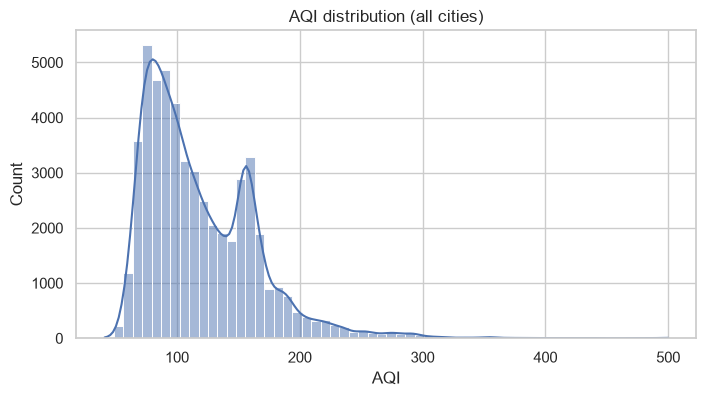

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df["aqi"], bins=60, kde=True)
plt.title("AQI distribution (all cities)")
plt.xlabel("AQI")
save_fig("aqi_distribution_all")
plt.show()

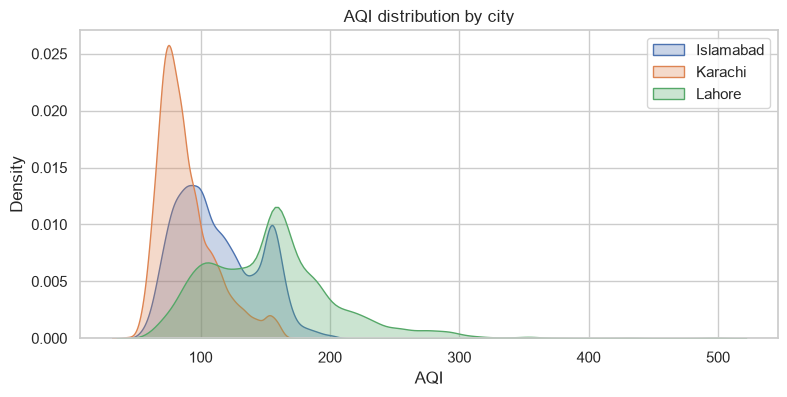

In [9]:
plt.figure(figsize=(9, 4))
for city, g in df.groupby("city"):
    sns.kdeplot(g["aqi"], label=city, fill=True, alpha=0.3)
plt.title("AQI distribution by city")
plt.xlabel("AQI")
plt.legend()
save_fig("aqi_distribution_by_city")
plt.show()

In [10]:
df.groupby("city")["aqi"].describe()[["mean", "50%", "std", "min", "max"]]

,mean,50%,std,min,max
city,,,,,
Islamabad,112.832873,107.0,31.063912,52.0,205.0
Karachi,88.502129,83.0,21.984269,41.0,172.0
Lahore,154.555421,154.0,51.164137,57.0,500.0


## **Notes**  
***AQI distribution:*** 
- The city with the highest median is ***Lahore*** can be seen from the table above.

> How Different are these 3 cities from eahc other?

These cities are very different based on the spread in the graph:
- **Karachi:** 
    It has the tightest but lowest distribution. Its orange curve is a tall narrow peak around 70-90. Coastal air, sea breeze clears pollution, so it stays mostly in the Moderate band and doesn't swing wildly. 

- **Islamabad:**
    it has the mean of 112.8, standard deviation of 31. Its like the Middle of the pack and it's curve is broader than Karachi which is shifted higher.

- **Lahore:**
    It has a mean of 154.5, standard deviation of 51. LAhore has Both the highest and the most variable and its standard deviation is more than double Karachi's. The green curve is wide and flat, spreads 200. That high variance is the winter smog sign whcih means Lahore has somewhat clean periods and some catastrophic ones, so it's spread is across a huge range rather than clustered.

> Is there a long tail of bad days?

Yes, and it's mostly Lahore's. Two things point to it:

- Lahore's max is 500 which is the top of the AQI scale and it is hazardous versus Karachi's max of just 172 and Islamabad's 205. So Lahore is the only city that reaches genuinely hazardous air.

- The cities histogram **(image 1)** which has a big hump around 70–90 and a distinct second hump around 150–170. That second bump is Lahore and Islamabad's worse hours pulling the combined distribution into two clusters. The right tail stretching out toward 300–500 is **Lahore**.

## 4. Time spent in each EPA category

Users care about the category (Good, Moderate, Unhealthy...) more than the exact
number.

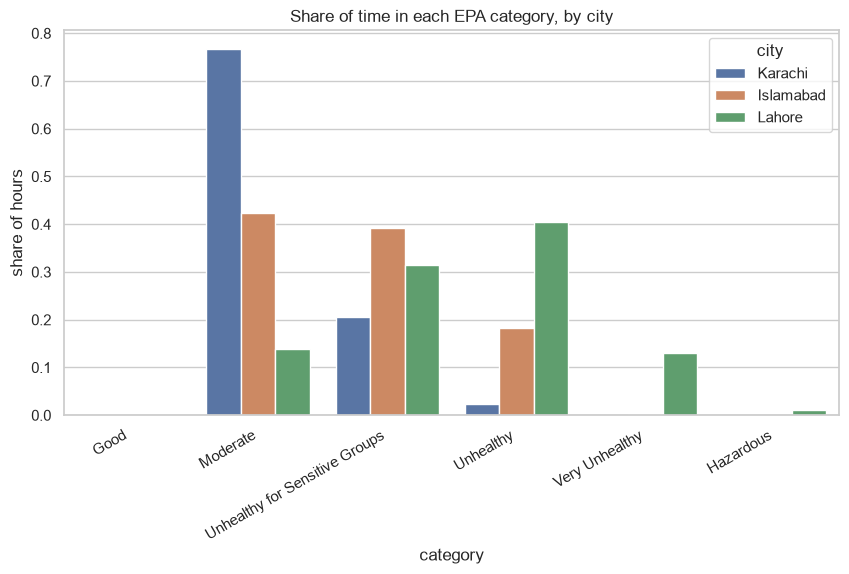

In [11]:
df["category"] = df["aqi"].map(lambda v: aqi_category(v)[0])

cat_order = ["Good", "Moderate", "Unhealthy for Sensitive Groups",
             "Unhealthy", "Very Unhealthy", "Hazardous"]

cat_pct = (df.groupby("city")["category"]
             .value_counts(normalize=True)
             .rename("share")
             .reset_index())
cat_pct["category"] = pd.Categorical(cat_pct["category"], cat_order, ordered=True)
cat_pct = cat_pct.sort_values("category")

plt.figure(figsize=(10, 5))
sns.barplot(data=cat_pct, x="category", y="share", hue="city")
plt.title("Share of time in each EPA category, by city")
plt.ylabel("share of hours")
plt.xticks(rotation=30, ha="right")
save_fig("epa_category_share")
plt.show()

## 5. Which pollutant drives AQI

AQI is the max of the pollutant subindices.

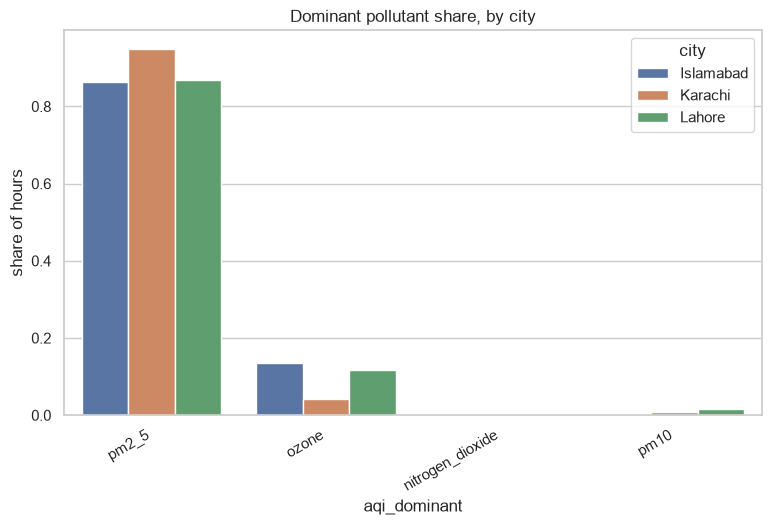

city,Islamabad,Karachi,Lahore
aqi_dominant,,,
nitrogen_dioxide,0.000115,0.000000,0.000000
ozone,0.135417,0.041206,0.116080
pm10,0.000000,0.008863,0.014791
pm2_5,0.864468,0.949931,0.869130


In [12]:
dom = (df.groupby("city")["aqi_dominant"]
         .value_counts(normalize=True)
         .rename("share")
         .reset_index())

plt.figure(figsize=(9, 5))
sns.barplot(data=dom, x="aqi_dominant", y="share", hue="city")
plt.title("Dominant pollutant share, by city")
plt.ylabel("share of hours")
plt.xticks(rotation=30, ha="right")
save_fig("dominant_pollutant_share")
plt.show()

dom.pivot(index="aqi_dominant", columns="city", values="share").fillna(0)

## Notes: AQI Distribution

**Which city has the highest median?**

Lahore, clearly. Median AQI is 154 for Lahore, 107 for Islamabad, and 83 for Karachi.
Worst to best is Lahore, then Islamabad, then Karachi.

**How different are these 3 cities from each other?**

They are very different, in both the level and the spread:

- **Karachi:** mean 88.5, std 22. It has the tightest and lowest distribution, a
  narrow peak around 70 to 90. Coastal air and sea breeze clear the pollution, so it
  mostly stays in the Moderate band and does not swing much.
- **Islamabad:** mean 112.8, std 31. Middle of the pack. Its curve is broader than
  Karachi and shifted higher.
- **Lahore:** mean 154.5, std 51. It is both the highest and the most variable, and
  its std is more than double Karachi's. The curve is wide and flat and spreads past
  200. That high variance is the winter smog sign, which means Lahore has some clean
  periods and some very bad ones, so it is spread across a huge range instead of
  clustered.

The gap is big, around 66 AQI points between Lahore's mean and Karachi's. A value of
120 is a bad day in Karachi but a good day in Lahore. This is why the pooled model
needs the per city features.

**Is there a long tail of bad days?**

Yes, and it is mostly Lahore's. Two things point to it:

- Lahore's max is 500, which is the top of the AQI scale and is Hazardous, while
  Karachi's max is only 172 and Islamabad's is 205. So Lahore is the only city that
  reaches genuinely hazardous air.
- The all cities histogram is bimodal, a big hump around 70 to 90 and a second hump
  around 150 to 170. That second bump is Lahore and Islamabad's worse hours pulling
  the combined distribution into two clusters. The right tail stretching out toward
  300 to 500 is almost all Lahore.

## 6. Daily, weekly, and seasonal patterns

Uses the stored `hour`, `day_of_week`, `month` columns (local time).

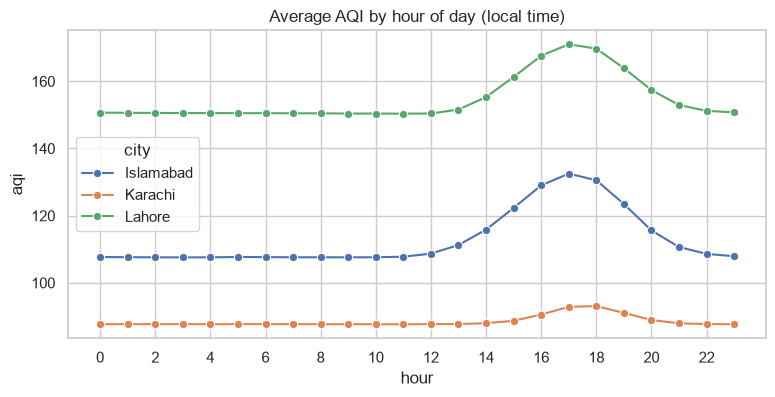

In [13]:
hourly = df.groupby(["city", "hour"])["aqi"].mean().reset_index()

plt.figure(figsize=(9, 4))
sns.lineplot(data=hourly, x="hour", y="aqi", hue="city", marker="o")
plt.title("Average AQI by hour of day (local time)")
plt.xlabel("hour")
plt.xticks(range(0, 24, 2))
save_fig("aqi_by_hour")
plt.show()

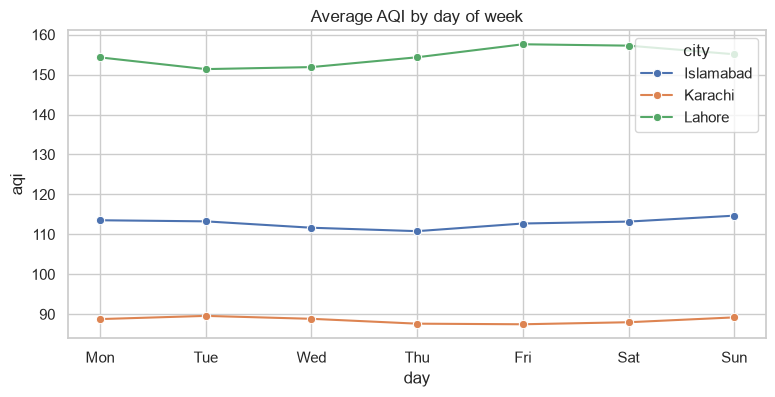

In [14]:
daily = df.groupby(["city", "day_of_week"])["aqi"].mean().reset_index()
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(9, 4))
sns.lineplot(data=daily, x="day_of_week", y="aqi", hue="city", marker="o")
plt.title("Average AQI by day of week")
plt.xlabel("day")
plt.xticks(range(7), day_names)
save_fig("aqi_by_dayofweek")
plt.show()

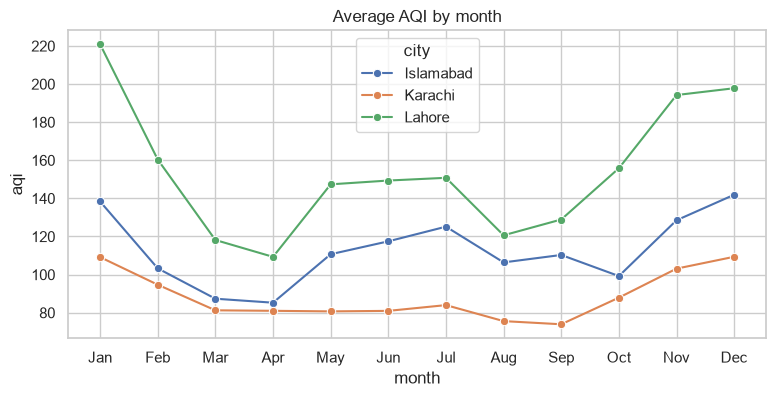

In [15]:
monthly = df.groupby(["city", "month"])["aqi"].mean().reset_index()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(9, 4))
sns.lineplot(data=monthly, x="month", y="aqi", hue="city", marker="o")
plt.title("Average AQI by month")
plt.xlabel("month")
plt.xticks(range(1, 13), month_names)
save_fig("aqi_by_month")
plt.show()

## Notes: Cycles

**Worst hour of day?** 

All three cities peak in the late afternoon around 5 to 6 pm and are lowest in the early morning, with Islamabad and Lahore showing the biggest daily swing while Karachi stays almost flat.

**Weekend effect?** 

Barely any, the day of week lines are nearly flat for all cities, so weekday vs weekend does not really change AQI here.

**Worst months?** 

Yes the winter spike is very clear, all cities are worst in Nov to Jan and cleanest around Mar to Apr and Aug to Sep, with Lahore hitting about 220 in January.

## 7. Weather and AQI

How AQI relates to weather, to confirm the weather features are worth including.

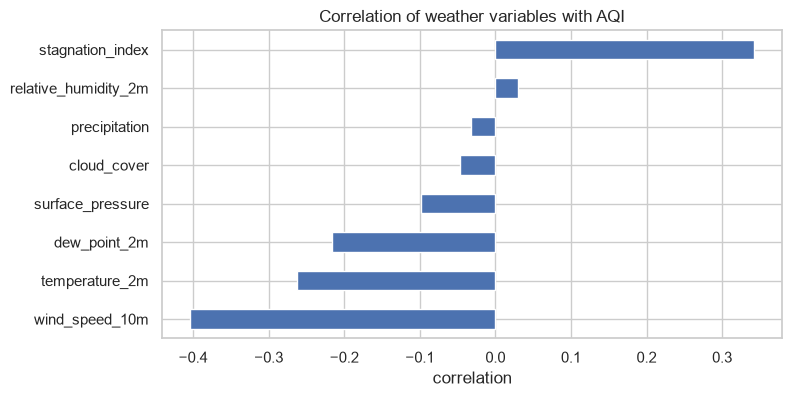

wind_speed_10m         -0.403668
temperature_2m         -0.262442
dew_point_2m           -0.216807
surface_pressure       -0.098831
cloud_cover            -0.046470
precipitation          -0.032431
relative_humidity_2m    0.029643
stagnation_index        0.342224
Name: aqi, dtype: float64

In [17]:
weather_cols = ["temperature_2m", "relative_humidity_2m", "dew_point_2m",
                "surface_pressure", "wind_speed_10m", "precipitation",
                "cloud_cover", "stagnation_index"]

corr = df[["aqi"] + weather_cols].corr()["aqi"].drop("aqi").sort_values()

plt.figure(figsize=(8, 4))
corr.plot(kind="barh")
plt.title("Correlation of weather variables with AQI")
plt.xlabel("correlation")
save_fig("weather_aqi_correlation")
plt.show()

corr

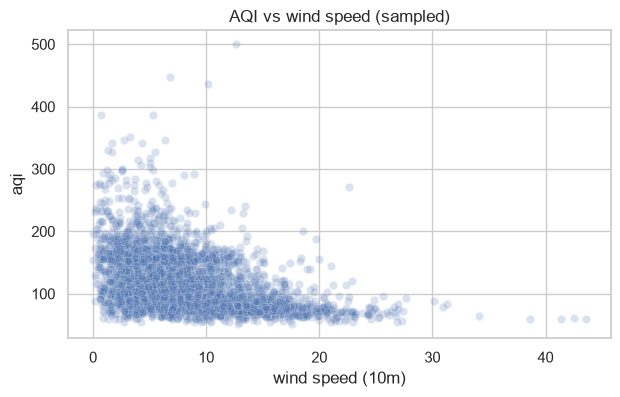

In [18]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df.sample(min(4000, len(df))),
                x="wind_speed_10m", y="aqi", alpha=0.2)
plt.title("AQI vs wind speed (sampled)")
plt.xlabel("wind speed (10m)")
save_fig("aqi_vs_windspeed")
plt.show()

## Notes: Weather

**Which variables relate most to AQI, and in which direction?** 

Wind speed is the strongest, negatively correlated at -0.40, so more wind means lower AQI. Stagnation index is next at +0.34 positive, meaning still high pressure air traps pollution. Temperature (-0.26) and dew point (-0.22) are moderate negatives, while the rest (pressure, cloud cover, precipitation, humidity) are weak.

**Does low wind go with high AQI?** 

Yes, clearly. The scatter plot shows the worst AQI values all happen at low wind speed, and AQI drops off as wind picks up. Wind and stagnation are the two weather features doing real work here.

## 8. Autocorrelation: how far back does the past matter

Justifies the lag features.

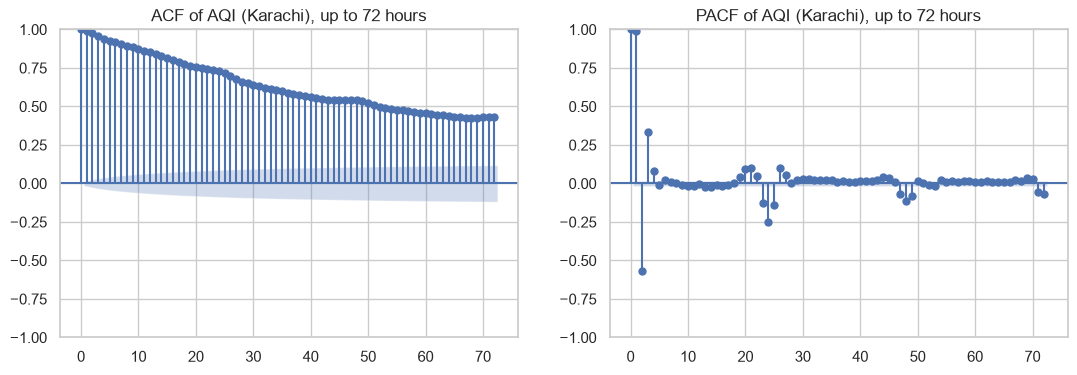

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

one = df[df["city_id"] == "pk-karachi"].sort_index()["aqi"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(one, lags=72, ax=axes[0])
axes[0].set_title("ACF of AQI (Karachi), up to 72 hours")
plot_pacf(one, lags=72, ax=axes[1], method="ywm")
axes[1].set_title("PACF of AQI (Karachi), up to 72 hours")
save_fig("aqi_acf_pacf")
plt.show()

## Notes: Autocorrelation

**How fast does the correlation fade?**

Very slowly. The ACF stays high, still around 0.75 at 12 hours and about 0.45 even at 72 hours, so AQI is strongly related to its own recent past. This means recent lags carry a lot of signal.

**A bump near 24h?** 

Yes, there is a small shoulder around the 24 hour mark in the ACF, showing the daily cycle. The PACF has its strongest spikes at lag 1 and 2 and a smaller one near 24, so most of the direct signal comes from the last few hours plus the same time yesterday.

**Is the lag set sensible?** 

Yes. The slow ACF decay justifies keeping the long lags (48, 72, 168), and the daily bump justifies the 24 hour lag. The lag set (1,2,3,6,12,24,48,72,168) looks well chosen.

## 9. Cross City comparison over time

The three cities on one timeline, averaged daily for readability.

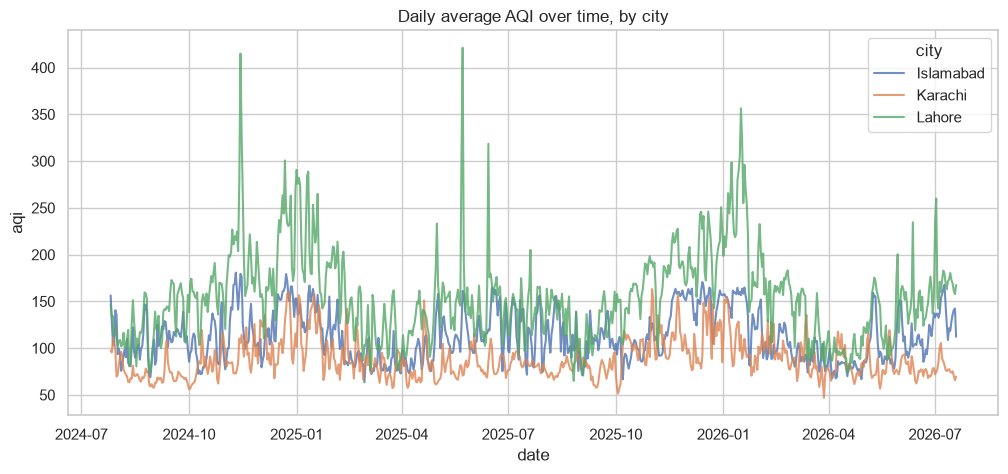

In [20]:
daily_avg = (df.groupby("city")["aqi"]
               .resample("D", level=0)
               .mean()
               .reset_index())

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_avg, x="timestamp", y="aqi", hue="city", alpha=0.8)
plt.title("Daily average AQI over time, by city")
plt.xlabel("date")
save_fig("aqi_timeline_by_city")
plt.show()

## Notes: Timeline

**Do the cities rise and fall together, or diverge?** 

They mostly rise and fall together, since they share the same seasons and weather. All three go up in the winter months and come down in summer. But they diverge in level, Lahore sits above the other two most of the time and Karachi stays lowest.

**Worst periods?** 

The two winters, around Dec 2024 to Jan 2025 and Dec 2025 to Jan 2026, are the worst for everyone. Lahore has some huge spikes past 400, and even a couple of sharp single day jumps above 400 in mid 2025 that stand out from the rest.